# Brain Tumor Segmentation - U-Net

**Dataset**: `mateuszbuda/lgg-mri-segmentation`  
**Task**: binary pixel-level segmentation of brain tumors on MRI  
**Architecture**: U-Net from scratch (PyTorch), logit output  
**Loss**: BCEWithLogitsLoss + Dice  
**Metrics**: Dice, IoU, Precision, Recall, Specificity, Accuracy


## 0. Dependencies

In [4]:
!pip install kagglehub scikit-learn pillow seaborn --quiet


In [5]:
import os
import glob
import random
from collections import defaultdict

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader

print('PyTorch:', torch.__version__)
print('CUDA:   ', torch.cuda.is_available())


PyTorch: 2.11.0+cu128
CUDA:    True


## 1. Config

In [6]:
IMG_SIZE     = 256
BATCH_SIZE   = 16
LR           = 1e-4
WEIGHT_DECAY = 1e-5
EPOCHS       = 15
PATIENCE     = 7        # EarlyStopping: stop after N epochs without improvement
CKPT_PATH    = 'unet_brain_tumor_best.pth'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


## 2. Patient-level split

The dataset has ~110 patients, each with 20-100 slices.  
**Critical**: split by *patient*, not by image — otherwise slices from the same patient
land in both train and test, inflating metrics.

Split: **70% train / 15% val / 15% test**


In [7]:
import kagglehub

path = kagglehub.dataset_download('mateuszbuda/lgg-mri-segmentation')
print('Dataset path:', path)

mask_paths  = sorted(glob.glob(os.path.join(path, '**', '*_mask.tif'), recursive=True))
image_paths = [p.replace('_mask.tif', '.tif') for p in mask_paths]
pairs       = [(img, msk) for img, msk in zip(image_paths, mask_paths) if os.path.exists(img)]
print(f'Valid image-mask pairs: {len(pairs)}')

# Each subfolder = one patient
patient_to_pairs = defaultdict(list)
for img, msk in pairs:
    patient_id = os.path.basename(os.path.dirname(img))
    patient_to_pairs[patient_id].append((img, msk))

patients = sorted(patient_to_pairs.keys())
print(f'Unique patients: {len(patients)}')

train_patients, temp_patients = train_test_split(patients, test_size=0.30, random_state=42)
val_patients,   test_patients = train_test_split(temp_patients, test_size=0.50, random_state=42)


def collect_paths(patient_list):
    imgs, msks = [], []
    for p in patient_list:
        for img, msk in patient_to_pairs[p]:
            imgs.append(img)
            msks.append(msk)
    return imgs, msks


train_imgs, train_msks = collect_paths(train_patients)
val_imgs,   val_msks   = collect_paths(val_patients)
test_imgs,  test_msks  = collect_paths(test_patients)

print(f'Train : {len(train_imgs):>5} images  ({len(train_patients)} patients)')
print(f'Val   : {len(val_imgs):>5} images  ({len(val_patients)} patients)')
print(f'Test  : {len(test_imgs):>5} images  ({len(test_patients)} patients)')


Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.
Dataset path: /kaggle/input/lgg-mri-segmentation
Valid image-mask pairs: 7858
Unique patients: 110
Train :  5500 images  (77 patients)
Val   :  1236 images  (16 patients)
Test  :  1122 images  (17 patients)


## 3. Dataset + Augmentation

New augmentations vs. original (hflip/vflip only):
- **Rotation** +/-15 degrees
- **Random zoom-in**: crop a sub-region, resize back
- **Brightness / contrast** jitter — image only, not mask

All joint transforms apply the **same random parameters** to both image and mask.


In [8]:
class BrainDataset(Dataset):
    def __init__(self, image_paths, mask_paths, augment=False):
        self.image_paths = list(image_paths)
        self.mask_paths  = list(mask_paths)
        self.augment     = augment

        self.img_transform = T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std =[0.229, 0.224, 0.225]),
        ])
        # NEAREST keeps mask edges crisp
        self.msk_transform = T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.NEAREST),
            T.ToTensor(),
        ])

    def _augment(self, img, msk):
        w, h = img.size
        if random.random() > 0.5:
            img = TF.hflip(img); msk = TF.hflip(msk)
        if random.random() > 0.5:
            img = TF.vflip(img); msk = TF.vflip(msk)
        # Rotation +/-15 degrees
        angle = random.uniform(-15, 15)
        img = TF.rotate(img, angle)
        msk = TF.rotate(msk, angle, interpolation=TF.InterpolationMode.NEAREST)
        # Random zoom-in (crop + resize back)
        if random.random() > 0.5:
            scale = random.uniform(0.75, 1.0)
            new_w = max(1, int(w * scale)); new_h = max(1, int(h * scale))
            left  = random.randint(0, w - new_w)
            top   = random.randint(0, h - new_h)
            img = TF.crop(img, top, left, new_h, new_w)
            msk = TF.crop(msk, top, left, new_h, new_w)
            img = TF.resize(img, [h, w])
            msk = TF.resize(msk, [h, w], interpolation=TF.InterpolationMode.NEAREST)
        # Brightness / contrast - image only
        if random.random() > 0.3:
            img = TF.adjust_brightness(img, random.uniform(0.75, 1.25))
        if random.random() > 0.3:
            img = TF.adjust_contrast(img, random.uniform(0.75, 1.25))
        return img, msk

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        msk = Image.open(self.mask_paths[idx]).convert('L')
        if self.augment:
            img, msk = self._augment(img, msk)
        img = self.img_transform(img)
        msk = self.msk_transform(msk)
        msk = (msk > 0.5).float()
        return img, msk


train_ds = BrainDataset(train_imgs, train_msks, augment=True)
val_ds   = BrainDataset(val_imgs,   val_msks,   augment=False)
test_ds  = BrainDataset(test_imgs,  test_msks,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

imgs, msks = next(iter(train_loader))
print(f'Batch: images={imgs.shape}  masks={msks.shape}  unique={msks.unique().tolist()}')


Batch: images=torch.Size([16, 3, 256, 256])  masks=torch.Size([16, 1, 256, 256])  unique=[0.0, 1.0]


## 4. Architecture - U-Net

```
INPUT          [B,   3, 256, 256]
enc1           [B,  64, 256, 256]  DoubleConv
enc2           [B, 128, 128, 128]  MaxPool + DoubleConv
enc3           [B, 256,  64,  64]  MaxPool + DoubleConv
enc4           [B, 512,  32,  32]  MaxPool + DoubleConv
bottleneck     [B,1024,  16,  16]  MaxPool + DoubleConv + Dropout2d(0.2)  
-------------------------------------------------------------------
dec4           [B, 512,  32,  32]  Upsample + cat(enc4) + DoubleConv
dec3           [B, 256,  64,  64]  Upsample + cat(enc3) + DoubleConv
dec2           [B, 128, 128, 128]  Upsample + cat(enc2) + DoubleConv
dec1           [B,  64, 256, 256]  Upsample + cat(enc1) + DoubleConv
OUTPUT         [B,   1, 256, 256]  Conv1x1  -- LOGITS
```


In [9]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        layers += [
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch, dropout=dropout))

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x, skip):
        x  = self.up(x)
        dh = skip.size(2) - x.size(2)
        dw = skip.size(3) - x.size(3)
        x  = F.pad(x, [dw // 2, dw - dw // 2, dh // 2, dh - dh // 2])
        return self.conv(torch.cat([skip, x], dim=1))


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.enc1       = DoubleConv(in_channels, 64)
        self.enc2       = Down(64,  128)
        self.enc3       = Down(128, 256)
        self.enc4       = Down(256, 512)
        self.bottleneck = Down(512, 1024, dropout=0.2)
        self.dec4       = Up(1024 + 512, 512)
        self.dec3       = Up( 512 + 256, 256)
        self.dec2       = Up( 256 + 128, 128)
        self.dec1       = Up( 128 +  64,  64)
        self.out_conv   = nn.Conv2d(64, out_channels, 1)  # -> logits

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        b  = self.bottleneck(s4)
        x  = self.dec4(b,  s4)
        x  = self.dec3(x,  s3)
        x  = self.dec2(x,  s2)
        x  = self.dec1(x,  s1)
        return self.out_conv(x)     # raw logits


model = UNet().to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
assert model(dummy).shape == (2, 1, IMG_SIZE, IMG_SIZE)
print(f'Shape check: [2,3,256,256] -> {model(dummy).shape}  OK')


Parameters: 31,384,833
Shape check: [2,3,256,256] -> torch.Size([2, 1, 256, 256])  OK


## 5. Loss + Optimizer

**BCEWithLogitsLoss** replaces `sigmoid -> BCELoss` — same math, but fused for numerical stability.

**Adam with `weight_decay=1e-5`** adds L2 regularisation.


In [10]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        p = probs.view(-1); t = targets.view(-1)
        intersection = (p * t).sum()
        return 1.0 - (2.0 * intersection + self.smooth) / (p.sum() + t.sum() + self.smooth)


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.bce  = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        return self.bce_weight * self.bce(logits, targets) + \
               (1 - self.bce_weight) * self.dice(logits, targets)


criterion = BCEDiceLoss(bce_weight=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)


## 6. Metrics

| Metric | Formula | Note |
|--------|---------|------|
| **Accuracy** | (TP+TN)/total | Misleading with class imbalance |
| **Precision** | TP/(TP+FP) | Of all pixels we called tumor, how many are |
| **Recall** | TP/(TP+FN) | Of all real tumor pixels, how many we found. Most important clinically |
| **F1 / Dice** | 2TP/(2TP+FP+FN) | Primary segmentation metric |
| **IoU** | TP/(TP+FP+FN) | Stricter than Dice, standard in papers |
| **Specificity** | TN/(TN+FP) | How well we ignore healthy tissue |


In [11]:
def compute_metrics(pred_binary, target):
    eps = 1e-8
    TP  = int(((pred_binary == 1) & (target == 1)).sum())
    TN  = int(((pred_binary == 0) & (target == 0)).sum())
    FP  = int(((pred_binary == 1) & (target == 0)).sum())
    FN  = int(((pred_binary == 0) & (target == 1)).sum())
    return {
        'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
        'accuracy':    (TP + TN) / (TP + TN + FP + FN + eps),
        'precision':   TP / (TP + FP + eps),
        'recall':      TP / (TP + FN + eps),
        'specificity': TN / (TN + FP + eps),
        'f1':          2 * TP / (2 * TP + FP + FN + eps),
        'iou':         TP / (TP + FP + FN + eps),
    }


## 7. EarlyStopping

In [12]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = float('inf')

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            return False
        self.counter += 1
        return self.counter >= self.patience


## 8. Train / Eval helpers

**`train_epoch`**: one pass, compute loss only (fast, no prediction collection during training).  
**`eval_epoch`**: one pass, compute loss AND metrics

In [13]:
def train_epoch(loader, model, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for imgs, msks in loader:
        imgs, msks = imgs.to(device), msks.to(device)
        logits = model(imgs)
        loss   = criterion(logits, msks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch(loader, model, criterion, threshold=0.5):
    model.eval()
    total_loss  = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for imgs, msks in loader:
            imgs, msks = imgs.to(device), msks.to(device)
            logits     = model(imgs)
            total_loss += criterion(logits, msks).item()
            preds_bin  = (torch.sigmoid(logits) > threshold).float().cpu()
            all_preds.append(preds_bin.view(-1).numpy())
            all_targets.append(msks.cpu().view(-1).numpy())
    all_preds   = np.concatenate(all_preds).astype(int)
    all_targets = np.concatenate(all_targets).astype(int)
    return total_loss / len(loader), compute_metrics(all_preds, all_targets), all_preds, all_targets


## 9. Training loop (up to 15 epochs + EarlyStopping)

In [14]:
history = {k: [] for k in ['train_loss', 'val_loss', 'dice', 'iou', 'precision', 'recall']}
best_val_loss = float('inf')
early_stop    = EarlyStopping(patience=PATIENCE)

header = f"{'Ep':>3}  {'Train':>8}  {'Val':>8}  {'Dice':>6}  {'IoU':>6}  {'Prec':>6}  {'Rec':>6}  {'LR':>8}"
print(header)
print('-' * len(header))

for epoch in range(1, EPOCHS + 1):
    train_loss            = train_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_m, _, _ = eval_epoch(val_loader, model, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['dice'].append(val_m['f1'])
    history['iou'].append(val_m['iou'])
    history['precision'].append(val_m['precision'])
    history['recall'].append(val_m['recall'])

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    marker = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CKPT_PATH)
        marker = ' [saved]'

    print(
        f'{epoch:>3}  {train_loss:>8.4f}  {val_loss:>8.4f}  '
        f"{val_m['f1']:>6.3f}  {val_m['iou']:>6.3f}  "
        f"{val_m['precision']:>6.3f}  {val_m['recall']:>6.3f}  "
        f'{current_lr:>8.2e}{marker}'
    )

    if early_stop(val_loss):
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        break

print('\nTraining complete.')


 Ep     Train       Val    Dice     IoU    Prec     Rec        LR
-----------------------------------------------------------------
  1    0.5636    0.5298   0.538   0.368   0.408   0.788  1.00e-04 [saved]
  2    0.4669    0.4483   0.705   0.544   0.699   0.712  1.00e-04 [saved]
  3    0.3732    0.3990   0.655   0.487   0.582   0.750  1.00e-04 [saved]
  4    0.2686    0.3693   0.666   0.500   0.838   0.553  1.00e-04 [saved]
  5    0.2090    0.3296   0.733   0.578   0.888   0.623  1.00e-04 [saved]
  6    0.1573    0.2999   0.732   0.577   0.731   0.734  1.00e-04 [saved]
  7    0.1523    0.2954   0.740   0.587   0.851   0.655  1.00e-04 [saved]
  8    0.1307    0.2792   0.772   0.628   0.845   0.710  1.00e-04 [saved]
  9    0.1180    0.2714   0.794   0.658   0.890   0.717  1.00e-04 [saved]
 10    0.1071    0.3155   0.717   0.558   0.911   0.590  1.00e-04
 11    0.1077    0.2628   0.791   0.654   0.878   0.719  1.00e-04 [saved]
 12    0.1032    0.2671   0.782   0.643   0.897   0.694  1.00e

## 10. Training curves

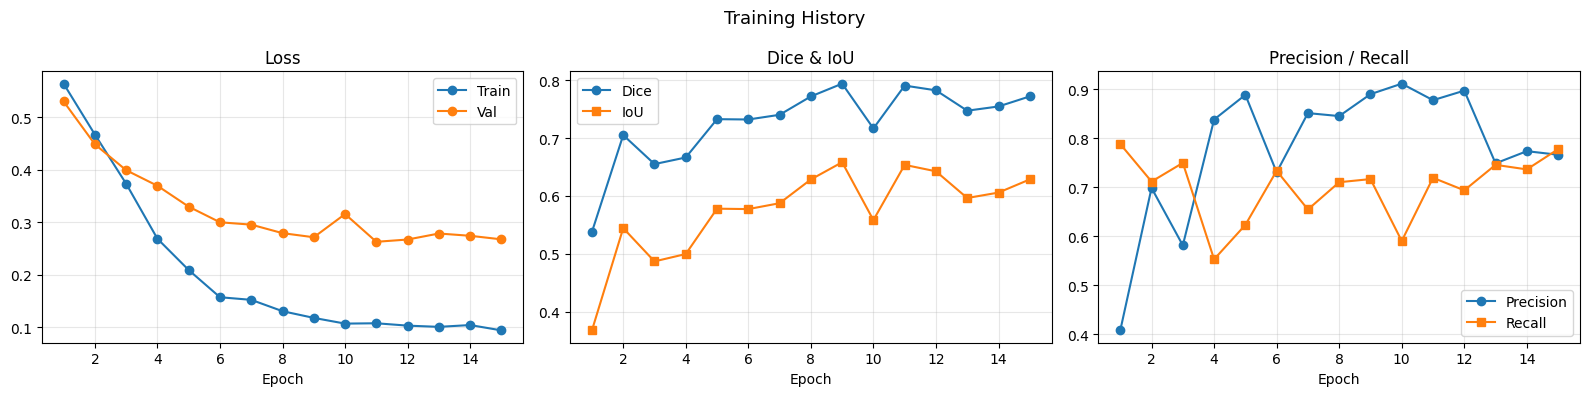

In [15]:
ep = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(ep, history['train_loss'], marker='o', label='Train')
axes[0].plot(ep, history['val_loss'],   marker='o', label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['dice'], marker='o', label='Dice')
axes[1].plot(ep, history['iou'],  marker='s', label='IoU')
axes[1].set_title('Dice & IoU'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history['precision'], marker='o', label='Precision')
axes[2].plot(ep, history['recall'],    marker='s', label='Recall')
axes[2].set_title('Precision / Recall'); axes[2].legend(); axes[2].grid(alpha=0.3)

for ax in axes:
    ax.set_xlabel('Epoch')
plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.show()


## 11. Threshold tuning on validation set

Instead of hardcoded 0.5, sweep thresholds on the **val set** and pick the one that maximises Dice.
The test set is never touched here.


Best threshold: 0.10  ->  Val Dice = 0.7936


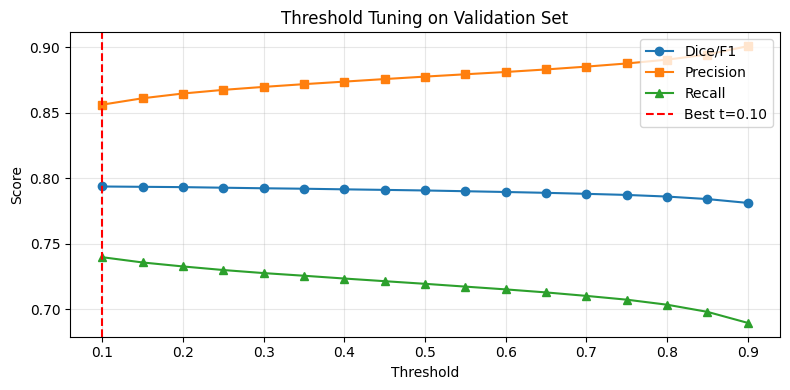

In [16]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()

all_probs_val, all_targets_val = [], []
with torch.no_grad():
    for imgs, msks in val_loader:
        logits = model(imgs.to(device))
        probs  = torch.sigmoid(logits).cpu()
        all_probs_val.append(probs.view(-1).numpy())
        all_targets_val.append(msks.view(-1).numpy())

all_probs_val   = np.concatenate(all_probs_val)
all_targets_val = np.concatenate(all_targets_val).astype(int)

sweep_results = []
for t in np.arange(0.10, 0.95, 0.05):
    preds = (all_probs_val > t).astype(int)
    m     = compute_metrics(preds, all_targets_val)
    sweep_results.append((round(t, 2), m['f1'], m['precision'], m['recall']))

best_t, best_val_dice, _, _ = max(sweep_results, key=lambda x: x[1])
print(f'Best threshold: {best_t:.2f}  ->  Val Dice = {best_val_dice:.4f}')

ts, f1s, precs, recs = zip(*sweep_results)
plt.figure(figsize=(8, 4))
plt.plot(ts, f1s,   marker='o', label='Dice/F1')
plt.plot(ts, precs, marker='s', label='Precision')
plt.plot(ts, recs,  marker='^', label='Recall')
plt.axvline(best_t, color='red', linestyle='--', label=f'Best t={best_t:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Threshold Tuning on Validation Set')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 12. Final evaluation on test set

Best checkpoint + tuned threshold. **First and only time we look at test set.**


In [17]:
test_loss, test_m, all_preds, all_targets = eval_epoch(
    test_loader, model, criterion, threshold=best_t
)

print('\n' + '=' * 42)
print('       FINAL TEST SET METRICS')
print('=' * 42)
print(f'  Checkpoint : {CKPT_PATH}')
print(f'  Threshold  : {best_t:.2f}  (tuned on val)')
print(f'  Test Loss  : {test_loss:.4f}')
print('-' * 42)
print(f"  Accuracy     : {test_m['accuracy']:.4f}")
print(f"  Precision    : {test_m['precision']:.4f}")
print(f"  Recall       : {test_m['recall']:.4f}")
print(f"  Specificity  : {test_m['specificity']:.4f}")
print(f"  F1 / Dice    : {test_m['f1']:.4f}")
print(f"  IoU (Jaccard): {test_m['iou']:.4f}")
print('-' * 42)
print(f"  TP: {test_m['TP']:>10,}   FP: {test_m['FP']:>10,}")
print(f"  FN: {test_m['FN']:>10,}   TN: {test_m['TN']:>10,}")
print('=' * 42)

print(classification_report(all_targets, all_preds,
                             target_names=['Background', 'Tumor'], digits=4))



       FINAL TEST SET METRICS
  Checkpoint : unet_brain_tumor_best.pth
  Threshold  : 0.10  (tuned on val)
  Test Loss  : 0.2175
------------------------------------------
  Accuracy     : 0.9932
  Precision    : 0.7698
  Recall       : 0.7148
  Specificity  : 0.9970
  F1 / Dice    : 0.7413
  IoU (Jaccard): 0.5889
------------------------------------------
  TP:    716,872   FP:    214,374
  FN:    286,006   TN: 72,314,140
              precision    recall  f1-score   support

  Background     0.9961    0.9970    0.9966  72528514
       Tumor     0.7698    0.7148    0.7413   1002878

    accuracy                         0.9932  73531392
   macro avg     0.8829    0.8559    0.8689  73531392
weighted avg     0.9930    0.9932    0.9931  73531392



## 13. Tumor-only metrics

~65% of slices have **no tumor** (empty mask). Including them inflates Accuracy and biases Dice.
This section evaluates only on slices where the ground-truth mask is non-empty.


In [18]:
tumor_preds, tumor_targets = [], []
model.eval()
with torch.no_grad():
    for imgs, msks in test_loader:
        logits    = model(imgs.to(device))
        preds_bin = (torch.sigmoid(logits) > best_t).float().cpu()
        for i in range(imgs.shape[0]):
            if msks[i].sum() > 0:
                tumor_preds.append(preds_bin[i].view(-1).numpy())
                tumor_targets.append(msks[i].view(-1).numpy())

if tumor_preds:
    tp_flat = np.concatenate(tumor_preds).astype(int)
    tt_flat = np.concatenate(tumor_targets).astype(int)
    tm      = compute_metrics(tp_flat, tt_flat)
    pct     = 100 * len(tumor_preds) / len(test_ds)
    print(f"{'=' * 42}")
    print(f'  TUMOR-ONLY: {len(tumor_preds)} / {len(test_ds)} images  ({pct:.1f}%)')
    print(f"{'=' * 42}")
    print(f"  F1 / Dice  : {tm['f1']:.4f}")
    print(f"  IoU        : {tm['iou']:.4f}")
    print(f"  Precision  : {tm['precision']:.4f}")
    print(f"  Recall     : {tm['recall']:.4f}")
    print(f"{'=' * 42}")


  TUMOR-ONLY: 448 / 1122 images  (39.9%)
  F1 / Dice  : 0.7557
  IoU        : 0.6074
  Precision  : 0.8016
  Recall     : 0.7148


## 14. Confusion Matrix

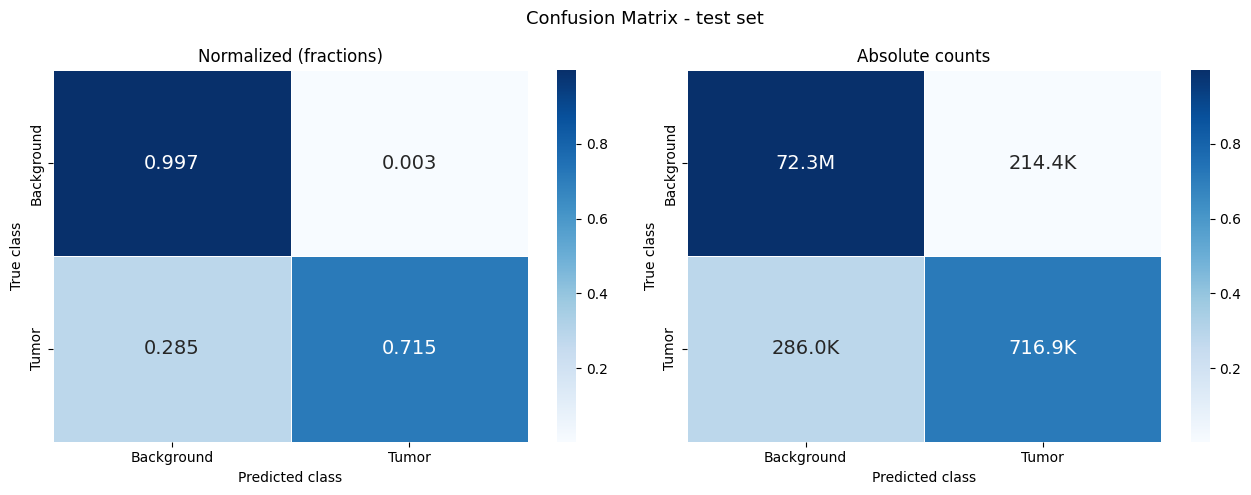

In [19]:
cm      = confusion_matrix(all_targets, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
labels  = ['Background', 'Tumor']


def fmt_count(n):
    if n >= 1_000_000: return f'{n / 1e6:.1f}M'
    if n >= 1_000:     return f'{n / 1e3:.1f}K'
    return str(n)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            ax=axes[0], linewidths=0.5, annot_kws={'size': 14})
axes[0].set_title('Normalized (fractions)')
axes[0].set_ylabel('True class'); axes[0].set_xlabel('Predicted class')

sns.heatmap(cm_norm, annot=np.vectorize(fmt_count)(cm), fmt='', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            ax=axes[1], linewidths=0.5, annot_kws={'size': 14})
axes[1].set_title('Absolute counts')
axes[1].set_ylabel('True class'); axes[1].set_xlabel('Predicted class')

plt.suptitle('Confusion Matrix - test set', fontsize=13)
plt.tight_layout(); plt.show()


## 15. Visual inspection

Randomly samples **only images with a tumor** (not empty scans) from the test set.
Overlay: **Green=TP**, **Red=FP**, **Blue=FN**.


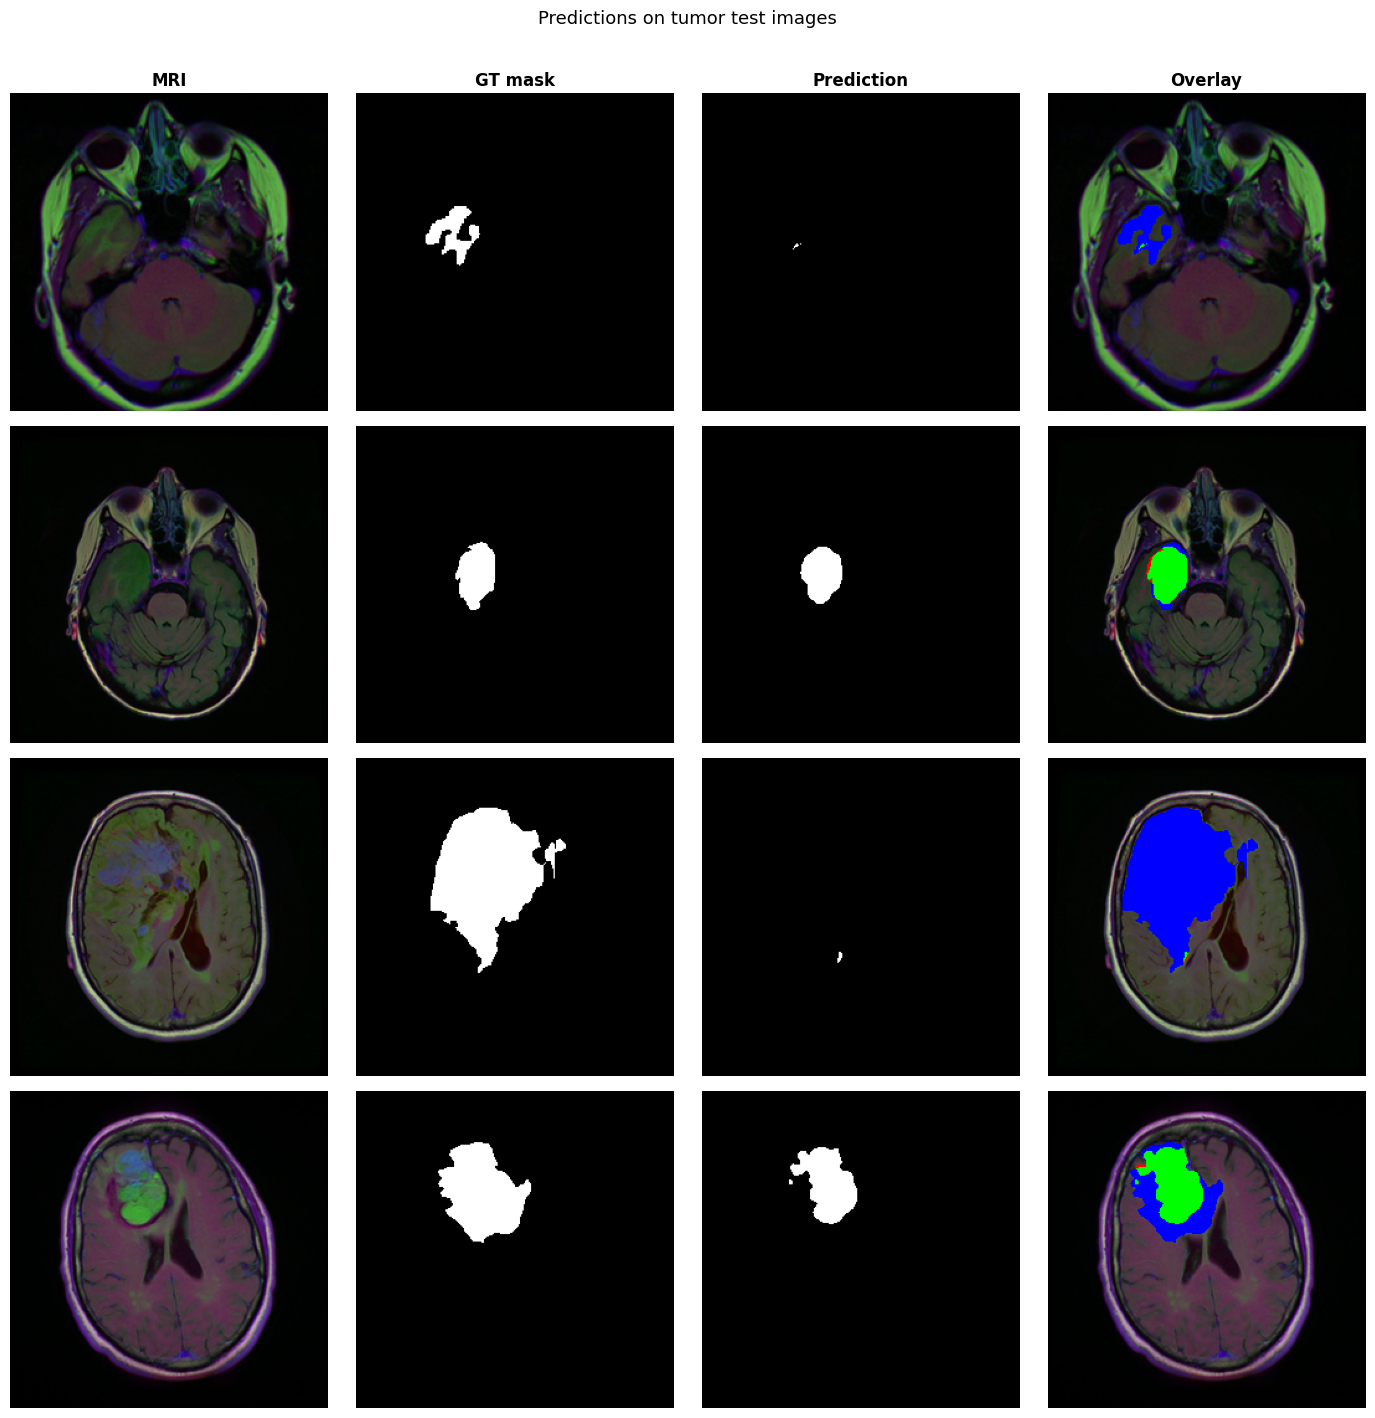

In [20]:
tumor_indices = [i for i in range(len(test_ds)) if test_ds[i][1].sum() > 0]
sample_idx    = random.sample(tumor_indices, min(4, len(tumor_indices)))

mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for ax, title in zip(axes[0], ['MRI', 'GT mask', 'Prediction', 'Overlay']):
    ax.set_title(title, fontsize=12, fontweight='bold')

model.eval()
with torch.no_grad():
    for row, idx in enumerate(sample_idx):
        img_t, msk_t = test_ds[idx]
        logits   = model(img_t.unsqueeze(0).to(device))
        pred_bin = (torch.sigmoid(logits).squeeze().cpu() > best_t).float()

        img_disp = (img_t * std_t + mean_t).permute(1, 2, 0).clamp(0, 1).numpy()
        msk_np   = msk_t.squeeze().numpy()
        pred_np  = pred_bin.numpy()

        overlay = img_disp.copy()
        overlay[(pred_np == 1) & (msk_np == 1)] = [0.0, 1.0, 0.0]  # TP green
        overlay[(pred_np == 1) & (msk_np == 0)] = [1.0, 0.0, 0.0]  # FP red
        overlay[(pred_np == 0) & (msk_np == 1)] = [0.0, 0.0, 1.0]  # FN blue

        m = compute_metrics(pred_np.flatten().astype(int), msk_np.flatten().astype(int))

        axes[row, 0].imshow(img_disp)
        axes[row, 1].imshow(msk_np,  cmap='gray')
        axes[row, 2].imshow(pred_np, cmap='gray')
        axes[row, 3].imshow(overlay)
        axes[row, 2].set_xlabel(
            f"Dice:{m['f1']:.3f}  IoU:{m['iou']:.3f}  Prec:{m['precision']:.3f}  Rec:{m['recall']:.3f}",
            fontsize=9,
        )
        axes[row, 3].set_xlabel('Green=TP  Red=FP  Blue=FN', fontsize=9)

for ax in axes.flat:
    ax.axis('off')
for ax in axes[:, 2:].flat:
    ax.xaxis.set_visible(True)
    ax.tick_params(bottom=False, labelbottom=True)

plt.suptitle('Predictions on tumor test images', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## 16. Save checkpoint with metadata

In [21]:
torch.save({
    'model_state_dict': model.state_dict(),
    'threshold':        best_t,
    'val_dice':         best_val_dice,
    'test_metrics':     test_m,
}, CKPT_PATH)
print(f'Saved: {CKPT_PATH}')

try:
    from google.colab import files
    files.download(CKPT_PATH)
except ImportError:
    print('File saved locally.')


Saved: unet_brain_tumor_best.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>